# EDA — Support Ticket Priority Dataset (50k) — treino

Exploração do dataset `ticket_prio_class/data/processed/train.csv`: tickets de suporte com atributos de contexto do cliente (porte, setor, tier de plano), do próprio chamado (canal, área de produto, sentimento) e sinais de impacto (usuários afetados, downtime, incidentes de segurança/perda de dados). Baixado do Kaggle via `get_dataset` e dividido em train/val/test por `main` (ambos em `ticket_prio_class/modeling/dataset.py`).

⚠️ **Este notebook usa só `train.csv`** — mesma disciplina do dataset irmão (`priority_classification/notebooks/1.0-eda-technical-support-dataset.ipynb`): qualquer decisão de atributo/pipeline deve vir só do que dá para ver em treino, para `val.csv`/`test.csv` continuarem sendo avaliação genuína, não parte da exploração.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ticket_prio_class.modeling.config import PROCESSED_DATA_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paleta categórica com ordem fixa (identidade da série nunca é ciclada por rank/posição)
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]
BLUE = CATEGORICAL_PALETTE[0]

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL_PALETTE),
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "font.size": 11,
})

DATASET_PATH = PROCESSED_DATA_DIR / "train.csv"
PRIORITY_ORDER = ["low", "medium", "high"]

2026-08-23 17:01:10.182 | INFO     | ticket_prio_class.modeling.config:<module>:11 - PROJ_ROOT path is: /home/caiobastos/Documentos/github/estudo_mentoria_caio_octavio/ticket_prio_class


## 1. Carregamento dos dados

In [2]:
df = pd.read_csv(DATASET_PATH)
print(f"shape: {df.shape}")
df.head()

shape: (34741, 33)


,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,org_users,region,region_cat,past_30d_tickets,past_90d_incidents,product_area,product_area_cat,booking_channel,booking_channel_cat,reported_by_role,reported_by_role_cat,customers_affected,error_rate_pct,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,101,AMER,1,2,3,analytics,5,chat,3,product_manager,3,24,2.495538,2,0,0,0,0,neutral,2,461,low,1
1,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,100,AMER,1,2,2,analytics,5,chat,3,finance,4,25,2.931906,16,0,0,0,1,neutral,2,363,medium,2
2,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,332,AMER,1,5,1,analytics,5,web,1,support,1,28,3.255222,6,0,0,0,0,neutral,2,442,low,1
3,1000000005,Thu,4,100022,Medium,2,saas_b2b,3,Enterprise,3,596,EMEA,2,3,3,auth,1,email,2,support,1,74,0.538945,13,0,0,0,1,neutral,2,349,medium,2
4,1000000008,Mon,1,100007,Large,3,media,7,Enterprise,3,5757,AMER,1,6,2,analytics,5,chat,3,finance,4,171,0.973382,3,0,0,0,0,neutral,2,432,medium,2


In [3]:
df.dtypes

ticket_id                   int64
day_of_week                   str
day_of_week_num             int64
company_id                  int64
company_size                  str
company_size_cat            int64
industry                      str
industry_cat                int64
customer_tier                 str
customer_tier_cat           int64
org_users                   int64
region                        str
region_cat                  int64
past_30d_tickets            int64
past_90d_incidents          int64
product_area                  str
product_area_cat            int64
booking_channel               str
booking_channel_cat         int64
reported_by_role              str
reported_by_role_cat        int64
customers_affected          int64
error_rate_pct            float64
downtime_min                int64
payment_impact_flag         int64
security_incident_flag      int64
data_loss_flag              int64
has_runbook                 int64
customer_sentiment            str
customer_senti

## 2. Estrutura básica e granularidade

`ticket_id` é a chave explícita do chamado. `company_id` é uma segunda entidade que se repete — poucas empresas, muitos tickets cada — bem diferente do dataset irmão (`Technical Support Dataset.csv`), que não tinha nenhum identificador de cliente/empresa.

In [4]:
print(f"nº de linhas: {len(df)}")
print("linhas totalmente duplicadas:", df.duplicated().sum())
print("'ticket_id' único:", df["ticket_id"].is_unique)
print("'ticket_id' min/max:", df["ticket_id"].min(), "a", df["ticket_id"].max())
print()
print("nº de empresas ('company_id') em treino:", df["company_id"].nunique())
print(df["company_id"].value_counts().describe().round(1))

nº de linhas: 34741
linhas totalmente duplicadas: 0
'ticket_id' único: True
'ticket_id' min/max: 1000000001 a 1000049998

nº de empresas ('company_id') em treino: 17
count      17.0
mean     2043.6
std       452.4
min      1445.0
25%      1619.0
50%      2086.0
75%      2228.0
max      2867.0
Name: count, dtype: float64


Nenhuma duplicata exata e `ticket_id` é único. O intervalo de `ticket_id` é quase tão largo quanto o dataset completo (50.000 tickets), mesmo em treino — ou seja, o split por `company_id` (feito em `dataset.py` para não vazar empresa entre treino/val/test) espalha os tickets de cada empresa por toda a linha do tempo original, não corta um bloco cronológico contínuo.

**Ponto de atenção:** só **17 empresas** caem em treino, cada uma com ~2.000 tickets. Isso importa para a seção 5: qualquer atributo que seja constante por empresa carrega, na prática, só 17 graus de liberdade reais — não 34.741, por mais linhas que tenha.

## 3. Nulos

In [5]:
missing = df.isna().sum().to_frame("nulos")
missing["% do total"] = (missing["nulos"] / len(df) * 100).round(1)
missing[missing["nulos"] > 0]

,nulos,% do total
customer_sentiment,645,1.9


In [6]:
print("customer_sentiment nulo × booking_channel:")
print(pd.crosstab(df["customer_sentiment"].isna(), df["booking_channel"]))

customer_sentiment nulo × booking_channel:
booking_channel     chat  email  phone    web
customer_sentiment                           
False               8168  10132   3598  12198
True                   0      0    645      0


**Achado de qualidade:** todo nulo de `customer_sentiment` vem de `booking_channel == "phone"` — nenhum nulo em `chat`/`email`/`web`. Mas não é "todo ticket por telefone é nulo": só uma fração deles (~15%) não tem sentimento capturado, os outros ~85% dos tickets por telefone têm sentimento normalmente. Hipótese razoável: sentimento é inferido de texto (chat/email/web sempre têm transcrição), e telefone só tem transcrição/análise de sentimento quando o atendimento passa por algum processo adicional (ex.: gravação transcrita).

## 4. Colunas `_cat`: mesma informação, já codificada como inteiro

Cada atributo categórico do dataset (inclusive o próprio `priority`) tem uma coluna-irmã `..._cat` com um código inteiro. Antes de tratá-las como atributos independentes, vale confirmar que são só a mesma informação em outro formato.

In [7]:
cat_pairs = [
    ("day_of_week", "day_of_week_num"),
    ("company_size", "company_size_cat"),
    ("industry", "industry_cat"),
    ("customer_tier", "customer_tier_cat"),
    ("region", "region_cat"),
    ("product_area", "product_area_cat"),
    ("booking_channel", "booking_channel_cat"),
    ("reported_by_role", "reported_by_role_cat"),
    ("customer_sentiment", "customer_sentiment_cat"),
    ("priority", "priority_cat"),
]

for raw_col, cat_col in cat_pairs:
    n_codes_per_category = df.groupby(raw_col, dropna=False)[cat_col].nunique()
    is_1to1 = (n_codes_per_category == 1).all()
    print(f"{raw_col:22s} -> {cat_col:24s} mapeamento 1:1 = {is_1to1}")

day_of_week            -> day_of_week_num          mapeamento 1:1 = True
company_size           -> company_size_cat         mapeamento 1:1 = True
industry               -> industry_cat             mapeamento 1:1 = True
customer_tier          -> customer_tier_cat        mapeamento 1:1 = True
region                 -> region_cat               mapeamento 1:1 = True
product_area           -> product_area_cat         mapeamento 1:1 = True
booking_channel        -> booking_channel_cat      mapeamento 1:1 = True
reported_by_role       -> reported_by_role_cat     mapeamento 1:1 = True
customer_sentiment     -> customer_sentiment_cat   mapeamento 1:1 = True
priority               -> priority_cat             mapeamento 1:1 = True


In [8]:
print("Códigos de customer_sentiment_cat:", sorted(df["customer_sentiment_cat"].unique()))
print(
    "customer_sentiment_cat quando customer_sentiment é nulo:",
    df.loc[df["customer_sentiment"].isna(), "customer_sentiment_cat"].unique(),
)

Códigos de customer_sentiment_cat: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
customer_sentiment_cat quando customer_sentiment é nulo: [0]


**Achado:** todo par é perfeitamente 1:1 — as colunas `_cat` são só a versão inteira das colunas string, sem nenhuma informação a mais. Vale notar que `customer_sentiment_cat` já trata o "nulo" da seção 3 como sua própria categoria (código `0`) em vez de deixá-lo como ausente — ou seja, a versão `_cat` já resolve a nulidade por conta própria.

**Implicação prática:** usar as duas versões (string e `_cat`) juntas como atributos seria redundante (a mesma informação duplicada); para modelagem, a versão `_cat` já vem pronta como inteiro, sem precisar de um encoder próprio — mas herda a mesma ressalva de qualquer integer encoding: os códigos não têm ordem real (`day_of_week_num` é uma exceção parcial, já que dia da semana tem uma ordem cíclica natural).

## 5. `company_id`: quais atributos são da empresa, e quais são do ticket?

Com só 17 empresas em treino (seção 2), importa separar o que é um atributo *firmográfico* (fixo por empresa, "vazado" para cada uma de suas ~2.000 linhas) do que de fato varia ticket a ticket — o mesmo cuidado que `1.0-eda-technical-support-dataset.ipynb` teve com `Latitude`/`Longitude` (constante por `Country`).

In [9]:
candidate_cols = [c for c in df.columns if c not in ("ticket_id", "company_id")]

static_per_company = {}
for col in candidate_cols:
    n_values_per_company = df.groupby("company_id")[col].nunique()
    static_per_company[col] = n_values_per_company.max() == 1

static_cols = [c for c, is_static in static_per_company.items() if is_static]
print("Colunas constantes dentro de cada empresa (atributos firmográficos):")
print(static_cols)

Colunas constantes dentro de cada empresa (atributos firmográficos):
['company_size', 'company_size_cat', 'industry', 'industry_cat', 'customer_tier', 'customer_tier_cat', 'org_users']


In [10]:
nunique_region_per_company = df.groupby("company_id")["region"].nunique()
multi_region_companies = nunique_region_per_company[nunique_region_per_company > 1]
print(f"'region' também é quase sempre constante por empresa, exceto {len(multi_region_companies)} empresas:")
print(df[df["company_id"].isin(multi_region_companies.index)].groupby(["company_id", "region"]).size())

'region' também é quase sempre constante por empresa, exceto 3 empresas:
company_id  region
100005      AMER      1556
            EMEA      1162
100007      AMER      1728
            EMEA      1139
100018      AMER      1682
            EMEA      1086
dtype: int64


**Achado de qualidade:** `company_size`, `industry`, `customer_tier` e `org_users` (mais suas versões `_cat`) são 100% constantes dentro de cada empresa — descrevem a empresa, não o chamado. `region` é quase sempre constante também, mas 3 das 17 empresas de treino têm tickets em 2 regiões (`AMER`/`EMEA`) com milhares de tickets em cada uma — parece uma empresa multinacional genuína, não ruído (a divisão não é um punhado de linhas isoladas).

**Implicação prática:** com só 17 empresas, tratar `company_size`/`industry`/`customer_tier`/`org_users` como atributos independentes é, na prática, uma forma indireta de usar `company_id` — um modelo pode aprender a reconhecer as 17 empresas vistas em treino em vez de um padrão firmográfico que generalize para empresas novas. Vale ter isso em mente ao interpretar importância de atributos em um notebook de modelagem.

## 6. Distribuição do target (`priority`) e das principais categóricas

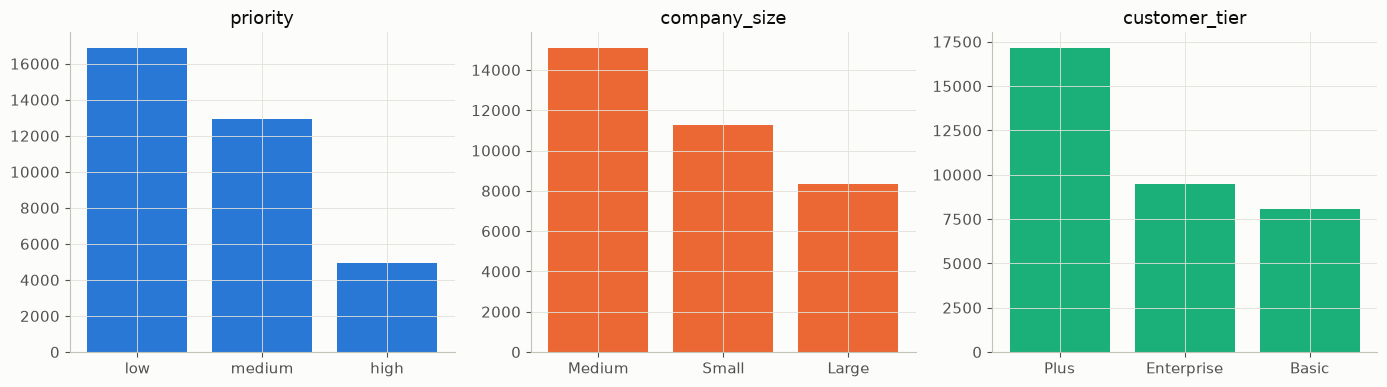

priority (%):
priority
low       48.6
medium    37.2
high      14.2
Name: proportion, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

priority_counts = df["priority"].value_counts().reindex(PRIORITY_ORDER)
axes[0].bar(priority_counts.index.astype(str), priority_counts.values, color=CATEGORICAL_PALETTE[0])
axes[0].set_title("priority")

size_counts = df["company_size"].value_counts()
axes[1].bar(size_counts.index.astype(str), size_counts.values, color=CATEGORICAL_PALETTE[1])
axes[1].set_title("company_size")

tier_counts = df["customer_tier"].value_counts()
axes[2].bar(tier_counts.index.astype(str), tier_counts.values, color=CATEGORICAL_PALETTE[2])
axes[2].set_title("customer_tier")

plt.tight_layout()
plt.show()

print("priority (%):")
print((df["priority"].value_counts(normalize=True) * 100).round(1))

`priority` é desbalanceada (`low` é a mais comum), mas de forma menos extrema que o dataset irmão. `company_size`/`customer_tier` também são desbalanceados — poucas empresas grandes/enterprise, mas cada uma contribui milhares de tickets (achado da seção 5), então a contagem de *tickets* aqui reflete o tamanho das empresas, não quantas empresas de cada tipo existem.

## 7. Há sinal nos atributos? (treino)

Mesma metodologia dos notebooks de `priority_classification`: desvio (em pontos percentuais) da proporção de cada `priority` dentro de cada categoria, em relação à taxa base. Diferente daquele dataset — onde nenhum atributo passava de ~11 p.p. — aqui já vale antecipar que vários atributos têm desvios bem maiores.

In [12]:
baseline_rate = df["priority"].value_counts(normalize=True).reindex(PRIORITY_ORDER) * 100
print("Taxa base de priority (treino):")
print(baseline_rate.round(1))


def priority_crosstab(data, col):
    """Proporção de cada priority dentro de cada categoria de `col`."""
    ct = pd.crosstab(data[col], data["priority"], normalize="index")
    return ct.reindex(columns=PRIORITY_ORDER).loc[data[col].value_counts().index]


def deviation_table(ct):
    """Desvio (em pontos percentuais) de cada célula em relação à taxa base."""
    return (ct * 100).sub(baseline_rate, axis=1)


def report_max_deviation(name, ct):
    max_dev = deviation_table(ct).abs().to_numpy().max()
    print(f"{name}: desvio máximo da taxa base = {max_dev:.1f} p.p. (n={len(ct)} categorias)")
    return max_dev


def quartile_bins(series):
    """Discretiza uma coluna contínua em até 4 faixas por quantil.

    `duplicates="drop"` colapsa faixas quando os quartis coincidem (ex.:
    `downtime_min` tem mais de 50% dos valores em 0 — os cortes dos quartis
    1-2-3 colapsam no mesmo valor) — nesse caso sobram menos de 4 faixas, e os
    labels ficam sendo os intervalos reais em vez de "Q1".."Q4" fixos, para não
    mentir sobre quantas faixas existem de fato.
    """
    return pd.qcut(series, q=4, duplicates="drop")

Taxa base de priority (treino):
priority
low       48.6
medium    37.2
high      14.2
Name: proportion, dtype: float64


In [13]:
CATEGORICAL_COLS = [
    "company_size",
    "industry",
    "customer_tier",
    "region",
    "product_area",
    "booking_channel",
    "reported_by_role",
    "customer_sentiment",
    "day_of_week",
]
FLAG_COLS = ["payment_impact_flag", "security_incident_flag", "data_loss_flag", "has_runbook"]
NUMERIC_COLS = [
    "org_users",
    "past_30d_tickets",
    "past_90d_incidents",
    "customers_affected",
    "error_rate_pct",
    "downtime_min",
    "description_length",
]

max_deviations = {}
for col in CATEGORICAL_COLS + FLAG_COLS:
    ct = priority_crosstab(df, col)
    max_deviations[col] = report_max_deviation(col, ct)

print()
for col in NUMERIC_COLS:
    binned_col = f"{col}_quartile"
    ct = priority_crosstab(df.assign(**{binned_col: quartile_bins(df[col])}), binned_col)
    max_deviations[col] = report_max_deviation(col, ct)

company_size: desvio máximo da taxa base = 35.2 p.p. (n=3 categorias)
industry: desvio máximo da taxa base = 24.3 p.p. (n=6 categorias)
customer_tier: desvio máximo da taxa base = 24.8 p.p. (n=3 categorias)


region: desvio máximo da taxa base = 17.8 p.p. (n=3 categorias)
product_area: desvio máximo da taxa base = 35.8 p.p. (n=6 categorias)
booking_channel: desvio máximo da taxa base = 11.1 p.p. (n=4 categorias)
reported_by_role: desvio máximo da taxa base = 26.2 p.p. (n=5 categorias)
customer_sentiment: desvio máximo da taxa base = 5.8 p.p. (n=3 categorias)
day_of_week: desvio máximo da taxa base = 2.0 p.p. (n=7 categorias)
payment_impact_flag: desvio máximo da taxa base = 25.8 p.p. (n=2 categorias)
security_incident_flag: desvio máximo da taxa base = 45.6 p.p. (n=2 categorias)
data_loss_flag: desvio máximo da taxa base = 27.8 p.p. (n=2 categorias)
has_runbook: desvio máximo da taxa base = 4.8 p.p. (n=2 categorias)

org_users: desvio máximo da taxa base = 35.2 p.p. (n=4 categorias)
past_30d_tickets: desvio máximo da taxa base = 24.8 p.p. (n=4 categorias)


past_90d_incidents: desvio máximo da taxa base = 15.8 p.p. (n=4 categorias)
customers_affected: desvio máximo da taxa base = 42.3 p.p. (n=4 categorias)


error_rate_pct: desvio máximo da taxa base = 21.5 p.p. (n=4 categorias)
downtime_min: desvio máximo da taxa base = 32.8 p.p. (n=2 categorias)
description_length: desvio máximo da taxa base = 27.0 p.p. (n=4 categorias)


In [14]:
print("Ranking de desvio máximo da taxa base, por atributo:")
print(pd.Series(max_deviations).sort_values(ascending=False).round(1))

Ranking de desvio máximo da taxa base, por atributo:
security_incident_flag    45.6
customers_affected        42.3
product_area              35.8
company_size              35.2
org_users                 35.2
downtime_min              32.8
data_loss_flag            27.8
description_length        27.0
reported_by_role          26.2
payment_impact_flag       25.8
customer_tier             24.8
past_30d_tickets          24.8
industry                  24.3
error_rate_pct            21.5
region                    17.8
past_90d_incidents        15.8
booking_channel           11.1
customer_sentiment         5.8
has_runbook                4.8
day_of_week                2.0
dtype: float64


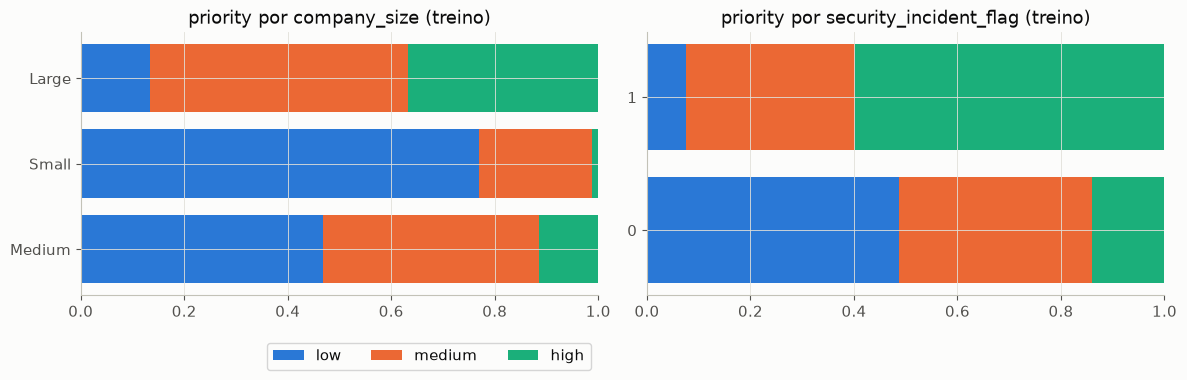

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ct_size = priority_crosstab(df, "company_size")
left = np.zeros(len(ct_size))
for priority, color in zip(PRIORITY_ORDER, CATEGORICAL_PALETTE):
    axes[0].barh(ct_size.index.astype(str), ct_size[priority], left=left, color=color, label=priority)
    left += ct_size[priority].to_numpy()
axes[0].set_xlim(0, 1)
axes[0].set_title("priority por company_size (treino)")
axes[0].legend(loc="upper right", bbox_to_anchor=(1.0, -0.15), ncol=3)

ct_sec = priority_crosstab(df, "security_incident_flag")
left = np.zeros(len(ct_sec))
for priority, color in zip(PRIORITY_ORDER, CATEGORICAL_PALETTE):
    axes[1].barh(ct_sec.index.astype(str), ct_sec[priority], left=left, color=color, label=priority)
    left += ct_sec[priority].to_numpy()
axes[1].set_xlim(0, 1)
axes[1].set_title("priority por security_incident_flag (treino)")

plt.tight_layout()
plt.show()

**Achado central — sinal forte e real, diferente do dataset irmão:**

Ranking de desvio máximo, do maior para o menor: `security_incident_flag` (45.6 p.p.), `customers_affected` (42.3 p.p.), `product_area` (35.8 p.p.), `company_size`/`org_users` (35.2 p.p., empatados — esperado, são o mesmo sinal de empresa visto na seção 5), `downtime_min` (32.8 p.p.), `data_loss_flag` (27.8 p.p.), `description_length` (27.0 p.p.), `reported_by_role` (26.2 p.p.), `payment_impact_flag` (25.8 p.p.), `customer_tier`/`past_30d_tickets` (24.8 p.p.), `industry` (24.3 p.p.), `error_rate_pct` (21.5 p.p.), `region` (17.8 p.p.), `past_90d_incidents` (15.8 p.p.), `booking_channel` (11.1 p.p.). No fim da fila: `customer_sentiment` (5.8 p.p.), `has_runbook` (4.8 p.p.) e `day_of_week` (2.0 p.p.) — os três com o menor desvio, coerente com `day_of_week` ter sido incluído de propósito como controle negativo (sem motivo causal para prever prioridade).

Alguns destaques:

- **Os flags raros dominam o topo** (`security_incident_flag`, `data_loss_flag`, `payment_impact_flag`): mesmo ocorrendo em só 0.3%–1.6% dos tickets, quando acontecem a proporção de `high` dispara muito acima da taxa base.
- **`description_length` (27.0 p.p.) é o atributo com mais sinal que não vem de contexto de empresa nem de flag de incidente** — mesmo sem um campo de texto livre disponível (diferente do dataset descartado em `discarted_datasets/`), o *tamanho* da descrição já carrega sinal real sobre prioridade.
- **`downtime_min` colapsou para só 2 faixas ao discretizar em quartis** (mais de 50% dos tickets têm `downtime_min == 0`, então os cortes dos quartis 1–3 coincidem — ver docstring de `quartile_bins`) — mesmo assim, essas 2 faixas (zero vs. algum downtime) já bastam para o segundo maior desvio entre as numéricas, 32.8 p.p.
- **`company_size`/`org_users` (35.2 p.p. cada)** são sinal de *empresa*, não de ticket (achado da seção 5) — o mesmo vale, em menor grau, para `industry`/`customer_tier`. Não é errado usá-los, mas o desvio alto aqui reflete só 17 empresas, não 34.741 observações independentes.

Isso contrasta diretamente com `priority_classification`, onde nenhum atributo elegível passava de ~11 p.p. e nenhum modelo batia um baseline aleatório: aqui há evidência clara, antes de qualquer modelo, de que os atributos carregam informação real sobre `priority`.

## 8. Sanidade dos atributos numéricos

In [16]:
df[NUMERIC_COLS].describe().round(2)

,org_users,past_30d_tickets,past_90d_incidents,customers_affected,error_rate_pct,downtime_min,description_length
count,34741.00,34741.00,34741.00,34741.00,34741.00,34741.00,34741.00
mean,1634.75,3.74,1.83,165.21,4.67,11.16,371.52
std,2162.43,2.70,1.45,390.43,4.72,17.31,101.95
min,73.00,0.00,0.00,0.00,0.00,0.00,20.00
25%,133.00,2.00,1.00,10.00,1.58,0.00,301.00
50%,572.00,3.00,2.00,34.00,3.25,0.00,370.00
75%,999.00,5.00,3.00,130.00,6.17,17.00,440.00
max,5757.00,19.00,10.00,5757.00,79.81,186.00,801.00


In [17]:
violations = (df["customers_affected"] > df["org_users"]).sum()
print(
    f"Tickets com customers_affected > org_users da própria empresa: {violations} "
    f"de {len(df)} ({violations / len(df) * 100:.2f}%)"
)

Tickets com customers_affected > org_users da própria empresa: 0 de 34741 (0.00%)


Nenhum valor negativo ou fora de faixa plausível em nenhuma coluna numérica, e `customers_affected` nunca excede `org_users` da própria empresa (checagem de consistência: 0 violações) — bom sinal de que esses campos foram gerados de forma coerente entre si, sem a inconsistência cronológica encontrada no dataset irmão.

## 9. Resumo dos principais achados

- **Estrutura básica:** 34.741 tickets em treino, chave explícita `ticket_id` (única, sem duplicatas). Segunda entidade, `company_id`, com só **17 empresas** em treino — bem diferente do dataset irmão, que não tinha nenhuma entidade repetida.
- **Nulos:** só `customer_sentiment` (1.9%), 100% restrito a `booking_channel == "phone"` — mas não todo ticket por telefone é nulo (só ~15% deles).
- **Colunas `_cat` são redundantes:** cada atributo categórico (inclusive `priority`) tem uma versão inteira 1:1 (`_cat`); usar as duas juntas duplicaria a mesma informação. `customer_sentiment_cat` já resolve o nulo como categoria própria (código `0`).
- **Atributos firmográficos são por empresa, não por ticket:** `company_size`, `industry`, `customer_tier` e `org_users` são 100% constantes dentro de cada uma das 17 empresas — carregam só 17 graus de liberdade reais, não 34.741. `region` é quase sempre constante também, com 3 exceções (empresas genuinamente multinacionais, com milhares de tickets em cada região). Usar esses atributos é, na prática, uma forma indireta de usar `company_id` — risco real de um modelo memorizar as 17 empresas vistas em treino em vez de generalizar.
- **Sinal forte e real, diferente de `priority_classification`** (onde nenhum atributo passava de ~11 p.p.): o ranking de desvio máximo vai de 45.6 p.p. (`security_incident_flag`) a 2.0 p.p. (`day_of_week`, incluído de propósito como controle negativo). Destaques: os *flags* raros de incidente (`security_incident_flag`, `data_loss_flag`, `payment_impact_flag`) dominam o topo apesar de raros (0.3%–1.6% dos tickets); `description_length` (27.0 p.p.) mostra sinal real mesmo sem nenhum campo de texto livre disponível; `downtime_min` colapsou para só 2 faixas ao discretizar (mais de 50% dos tickets têm `downtime_min == 0`) mas ainda assim rendeu 32.8 p.p. de desvio.
- **Sem inconsistências de integridade:** nenhuma coluna numérica com valores negativos/implausíveis, e `customers_affected` nunca excede `org_users` — nenhuma violação, diferente da inconsistência cronológica encontrada no dataset irmão.

## 10. Próximos passos

1. **Separar sinal de empresa e sinal de ticket ao construir features** — dado o achado da seção 5, qualquer notebook de modelagem deveria decidir explicitamente se quer usar atributos firmográficos (com o risco de memorizar as 17 empresas) e, se usar, avaliar com um split que já é por empresa (`ticket_prio_class/modeling/dataset.py` já faz isso) para não mascarar esse risco.
2. **Aproveitar o sinal real encontrado na seção 7** — ao contrário do dataset irmão, aqui há uma base concreta para esperar que um classificador supere um baseline aleatório; os flags raros de incidente, `customers_affected`, `product_area` e `description_length` são os primeiros candidatos, por combinarem desvio alto com não dependerem só da identidade da empresa.
3. **Evitar redundância** entre a versão string e `_cat` de cada atributo (seção 4) ao montar o pipeline de features.
4. **Tratar `downtime_min` com cuidado na binarização/discretização** — dado o colapso de faixas visto na seção 7, uma feature binária (`downtime_min == 0` vs. `> 0`) pode já capturar a maior parte do sinal, sem necessidade de quartis.
5. **Registrar que esta é uma exploração só de treino** — antes de qualquer avaliação de modelo, `val.csv`/`test.csv` continuam intocados.